# Confusion Matrix for Missing Component Detection (PCB-MC)

This notebook generates confusion matrices from YOLO detection results on the
**PCB-MC-M** (missing_only) subset under board-identity-aware 5-fold cross-validation.

## What it does

1. Loads ground-truth YOLO labels and model predictions for each fold
2. Matches predictions to ground-truth boxes using IoU
3. Builds a confusion matrix: 8 missing classes + Background (FP/FN)
4. Aggregates across all 5 folds
5. Produces a publication-quality figure

## Requirements

- YOLO validation results must have been saved (labels in `runs/detect/*/labels/`)
- OR you re-run inference here using saved checkpoints

---
## [0] Mount Drive & Install Dependencies

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install ultralytics --quiet
!pip install seaborn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 39.6 MB/s eta 0:00:00


---
## [1] Configuration

In [ ]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
from PIL import Image

# ============================================================
# PATHS — Update these to match your Drive structure
# ============================================================

DATA_ROOT = '/content/drive/MyDrive/PCB_MC/Data/'

# Dataset subset to evaluate (missing_only = PCB-MC-M)
SUBSET = 'missing_only'

# Number of folds
N_FOLDS = 5

# Which model to evaluate
# Options: 'yolov8', 'yolov11', 'yolo26', 'rtdetr', 'dfine'
MODEL_NAME = 'yolov11'

# Path to saved model checkpoints (one per fold)
# Update this pattern to match where your trained weights are stored
# The {} will be replaced with the fold number (0-4)
#CHECKPOINT_PATTERN = os.path.join(
 #   DATA_ROOT, SUBSET, 'kfold_data', 'fold_{}', 'weights', 'best.pt'
#)

# Alternative: if you stored checkpoints elsewhere
CHECKPOINT_PATTERN = '/content/drive/MyDrive/PCB_MC/Results/YOLOV11/missing_only/fold_{}/weights/best.pt'

# IoU threshold for matching predictions to ground truth
IOU_THRESHOLD = 0.5

# Confidence threshold for predictions
CONF_THRESHOLD = 0.25

# Image size used during training
IMG_SIZE = 1024

# The 8 missing component class names (PCB-MC-M)
MISSING_CLASSES = [
    'Missing Capacitor',
    'Missing Component',
    'Missing Diode',
    'Missing Ferrite Bead',
    'Missing IC',
    'Missing Inductor',
    'Missing LED',
    'Missing Resistor',
]

# Output directory for figures
OUTPUT_DIR = '/content/drive/MyDrive/PCB_MC/figures'
os.makedirs(OUTPUT_DIR, exist_ok=True)

IMG_EXTS = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

print(f'Model:     {MODEL_NAME}')
print(f'Subset:    {SUBSET}')
print(f'Folds:     {N_FOLDS}')
print(f'IoU thr:   {IOU_THRESHOLD}')
print(f'Conf thr:  {CONF_THRESHOLD}')
print(f'Classes:   {len(MISSING_CLASSES)}')
print(f'Output:    {OUTPUT_DIR}')

Model:     yolov11
Subset:    missing_only
Folds:     5
IoU thr:   0.5
Conf thr:  0.25
Classes:   8
Output:    /content/drive/MyDrive/PCB_MC/figures


---
## [2] Helper Functions

Core utilities for reading YOLO labels, computing IoU, and matching
predictions to ground-truth boxes.

In [ ]:
def read_yolo_labels(label_path):
    """
    Read a YOLO format label file.
    Returns list of (class_id, x_center, y_center, width, height).
    All coordinates are normalized [0, 1].
    """
    boxes = []
    if not os.path.exists(label_path):
        return boxes
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls_id = int(float(parts[0]))
            cx, cy, w, h = map(float, parts[1:5])
            boxes.append((cls_id, cx, cy, w, h))
    return boxes


def yolo_to_xyxy(cx, cy, w, h):
    """
    Convert YOLO normalized (cx, cy, w, h) to (x1, y1, x2, y2).
    Still in normalized coordinates.
    """
    x1 = cx - w / 2
    y1 = cy - h / 2
    x2 = cx + w / 2
    y2 = cy + h / 2
    return x1, y1, x2, y2


def compute_iou(box1, box2):
    """
    Compute IoU between two boxes in (x1, y1, x2, y2) format.
    """
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - inter

    if union <= 0:
        return 0.0
    return inter / union


def match_predictions_to_gt(gt_boxes, pred_boxes, iou_threshold=0.5):
    """
    Match predicted boxes to ground-truth boxes using IoU.

    Args:
        gt_boxes: list of (class_id, x1, y1, x2, y2)
        pred_boxes: list of (class_id, x1, y1, x2, y2, conf)
        iou_threshold: minimum IoU to count as a match

    Returns:
        matches: list of (gt_class, pred_class) for matched pairs
        unmatched_gt: list of gt_class for missed ground-truth (FN)
        unmatched_pred: list of pred_class for false positives (FP)
    """
    # Sort predictions by confidence (highest first)
    pred_boxes = sorted(pred_boxes, key=lambda x: x[5], reverse=True)

    matched_gt_indices = set()
    matches = []
    unmatched_pred = []

    for pred in pred_boxes:
        pred_cls = pred[0]
        pred_xyxy = pred[1:5]

        best_iou = 0
        best_gt_idx = -1

        for gt_idx, gt in enumerate(gt_boxes):
            if gt_idx in matched_gt_indices:
                continue
            gt_xyxy = gt[1:5]
            iou = compute_iou(pred_xyxy, gt_xyxy)
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = gt_idx

        if best_iou >= iou_threshold and best_gt_idx >= 0:
            gt_cls = gt_boxes[best_gt_idx][0]
            matches.append((gt_cls, pred_cls))
            matched_gt_indices.add(best_gt_idx)
        else:
            unmatched_pred.append(pred_cls)

    # Unmatched ground-truth boxes are false negatives
    unmatched_gt = [
        gt_boxes[i][0] for i in range(len(gt_boxes))
        if i not in matched_gt_indices
    ]

    return matches, unmatched_gt, unmatched_pred


def get_label_path(img_path):
    """Convert an image path to its corresponding label path."""
    return img_path.replace('/images/', '/labels/').rsplit('.', 1)[0] + '.txt'


def list_images(folder):
    """List all image files in a folder."""
    if not os.path.exists(folder):
        return []
    return sorted([
        os.path.join(folder, f) for f in os.listdir(folder)
        if f.lower().endswith(IMG_EXTS)
    ])

print('Helper functions defined.')

Helper functions defined.


---
## [3] Run Inference or Load Existing Predictions

**Option A:** Run YOLO inference on validation images for each fold.
This saves prediction labels to disk.

**Option B:** If you already have prediction labels saved from previous
training runs, skip this cell and set `PRED_LABELS_PATTERN` in the next cell.

Uncomment the option you need.

In [ ]:
# ============================================================
# OPTION A: Run inference from checkpoints
# ============================================================

from ultralytics import YOLO

PRED_DIRS = {}  # fold -> directory with predicted labels

for fold in range(N_FOLDS):
    print(f'\n--- Fold {fold} ---')

    # Load checkpoint
    ckpt_path = CHECKPOINT_PATTERN.format(fold)
    if not os.path.exists(ckpt_path):
        print(f'  Checkpoint not found: {ckpt_path}')
        print(f'  Trying alternative path...')
        # Try common alternative locations
        alternatives = [
            f'/content/drive/MyDrive/PCB_MC/checkpoints/{MODEL_NAME}_fold_{fold}/best.pt',
            f'/content/drive/MyDrive/PCB_MC/runs/{MODEL_NAME}/fold_{fold}/weights/best.pt',
        ]
        for alt in alternatives:
            if os.path.exists(alt):
                ckpt_path = alt
                print(f'  Found: {alt}')
                break
        else:
            print(f'  SKIP fold {fold}: no checkpoint found')
            continue

    model = YOLO(ckpt_path)

    # Validation images for this fold
    val_img_dir = os.path.join(
        DATA_ROOT, SUBSET, 'kfold_data', f'fold_{fold}', 'valid', 'images'
    )
    val_images = list_images(val_img_dir)
    print(f'  Val images: {len(val_images)}')

    if len(val_images) == 0:
        print(f'  SKIP fold {fold}: no validation images')
        continue

    # Run inference and save labels
    results = model.predict(
        source=val_img_dir,
        imgsz=IMG_SIZE,
        conf=CONF_THRESHOLD,
        save_txt=True,
        save_conf=True,
        project='/content/cm_preds',
        name=f'{MODEL_NAME}_fold_{fold}',
        exist_ok=True,
    )

    pred_label_dir = os.path.join(
        '/content/cm_preds', f'{MODEL_NAME}_fold_{fold}', 'labels'
    )
    PRED_DIRS[fold] = pred_label_dir
    n_pred_files = len(list(Path(pred_label_dir).glob('*.txt'))) if os.path.exists(pred_label_dir) else 0
    print(f'  Predictions saved: {n_pred_files} label files')

print(f'\nInference complete for {len(PRED_DIRS)} folds.')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

--- Fold 0 ---
  Val images: 59

image 1/59 /content/drive/MyDrive/PCB_MC/Data/missing_only/kfold_data/fold_0/valid/images/ACM-109_Bottom_jpg.rf.8ab9d5f11d0e003f2c6c8c96e8a527a7.jpg: 1024x832 3 Missing Resistors, 53.7ms
image 2/59 /content/drive/MyDrive/PCB_MC/Data/missing_only/kfold_data/fold_0/valid/images/ACM-109_Bottom_jpg.rf.ba1019569b63a920a2fecd4800730082.jpg: 1024x832 3 Missing Resistors, 27.9ms
image 3/59 /content/drive/MyDrive/PCB_MC/Data/missing_only/kfold_data/fold_0/valid/images/ACM-109_Bottom_jpg.rf.f8f24f0b3b3ac95e0fa31abdb94ad873.jpg: 1024x832 3 Missing Resistors, 27.9ms
image 4/59 /content/drive/MyDrive/PCB_MC/Data/missing_only/kfold_data/fold_0/valid/images/Arty

In [ ]:
# ============================================================
# OPTION B: Use existing prediction labels
# Uncomment and update the pattern below if you already have
# prediction labels saved from previous runs.
# ============================================================

# PRED_DIRS = {}
# for fold in range(N_FOLDS):
#     pred_dir = f'/content/drive/MyDrive/PCB_MC/runs/{MODEL_NAME}/fold_{fold}/labels'
#     if os.path.exists(pred_dir):
#         PRED_DIRS[fold] = pred_dir
#         print(f'Fold {fold}: {pred_dir}')
#     else:
#         print(f'Fold {fold}: NOT FOUND at {pred_dir}')

---
## [4] Build Confusion Matrix Across All Folds

For each fold, we:
1. Read ground-truth labels from the validation split
2. Read predicted labels from the inference output
3. Match predictions to GT using IoU
4. Accumulate counts into the confusion matrix

The matrix has shape `(N+1) x (N+1)` where N = 8 missing classes.
The extra row/column represents **Background** (unmatched GT = FN row,
unmatched predictions = FP column).

In [ ]:
num_classes = len(MISSING_CLASSES)
# Matrix shape: (num_classes + 1) x (num_classes + 1)
# Rows = ground truth, Columns = predictions
# Last row/col = Background (FN / FP)
cm_all = np.zeros((num_classes + 1, num_classes + 1), dtype=int)

# Also store per-fold matrices for reporting std
cm_per_fold = []

total_gt = 0
total_pred = 0
total_matched = 0

for fold in range(N_FOLDS):
    if fold not in PRED_DIRS:
        print(f'Fold {fold}: skipped (no predictions)')
        continue

    print(f'\n--- Fold {fold} ---')

    # Ground-truth label directory
    gt_label_dir = os.path.join(
        DATA_ROOT, SUBSET, 'kfold_data', f'fold_{fold}', 'valid', 'labels'
    )
    # Predicted label directory
    pred_label_dir = PRED_DIRS[fold]

    # Get all validation images
    val_img_dir = os.path.join(
        DATA_ROOT, SUBSET, 'kfold_data', f'fold_{fold}', 'valid', 'images'
    )
    val_images = list_images(val_img_dir)

    cm_fold = np.zeros((num_classes + 1, num_classes + 1), dtype=int)
    fold_gt = 0
    fold_pred = 0
    fold_matched = 0

    for img_path in val_images:
        img_stem = Path(img_path).stem

        # Read ground-truth
        gt_label_path = os.path.join(gt_label_dir, img_stem + '.txt')
        gt_raw = read_yolo_labels(gt_label_path)
        gt_boxes = [
            (cls_id, *yolo_to_xyxy(cx, cy, w, h))
            for cls_id, cx, cy, w, h in gt_raw
        ]

        # Read predictions (YOLO save_txt format: cls cx cy w h conf)
        pred_label_path = os.path.join(pred_label_dir, img_stem + '.txt')
        pred_raw = []
        if os.path.exists(pred_label_path):
            with open(pred_label_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 6:
                        continue
                    cls_id = int(float(parts[0]))
                    cx, cy, w, h = map(float, parts[1:5])
                    conf = float(parts[5])
                    x1, y1, x2, y2 = yolo_to_xyxy(cx, cy, w, h)
                    pred_raw.append((cls_id, x1, y1, x2, y2, conf))

        fold_gt += len(gt_boxes)
        fold_pred += len(pred_raw)

        # Match predictions to GT
        matches, unmatched_gt, unmatched_pred = match_predictions_to_gt(
            gt_boxes, pred_raw, iou_threshold=IOU_THRESHOLD
        )
        fold_matched += len(matches)

        # Fill confusion matrix
        # Correct matches and misclassifications
        for gt_cls, pred_cls in matches:
            if gt_cls < num_classes and pred_cls < num_classes:
                cm_fold[gt_cls, pred_cls] += 1

        # False negatives: GT boxes with no matching prediction
        for gt_cls in unmatched_gt:
            if gt_cls < num_classes:
                cm_fold[gt_cls, num_classes] += 1  # GT row, Background col

        # False positives: predictions with no matching GT
        for pred_cls in unmatched_pred:
            if pred_cls < num_classes:
                cm_fold[num_classes, pred_cls] += 1  # Background row, pred col

    cm_all += cm_fold
    cm_per_fold.append(cm_fold)

    total_gt += fold_gt
    total_pred += fold_pred
    total_matched += fold_matched

    print(f'  GT boxes:    {fold_gt}')
    print(f'  Predictions: {fold_pred}')
    print(f'  Matched:     {fold_matched}')
    print(f'  FN (missed): {fold_gt - fold_matched}')
    print(f'  FP:          {fold_pred - fold_matched}')

print(f'\n=== Totals across all folds ===')
print(f'GT boxes:    {total_gt}')
print(f'Predictions: {total_pred}')
print(f'Matched:     {total_matched}')
print(f'FN:          {total_gt - total_matched}')
print(f'FP:          {total_pred - total_matched}')


--- Fold 0 ---
  GT boxes:    1394
  Predictions: 495
  Matched:     277
  FN (missed): 1117
  FP:          218

--- Fold 1 ---
  GT boxes:    1129
  Predictions: 270
  Matched:     134
  FN (missed): 995
  FP:          136

--- Fold 2 ---
  GT boxes:    1641
  Predictions: 473
  Matched:     245
  FN (missed): 1396
  FP:          228

--- Fold 3 ---
  GT boxes:    2602
  Predictions: 357
  Matched:     205
  FN (missed): 2397
  FP:          152

--- Fold 4 ---
  GT boxes:    2668
  Predictions: 153
  Matched:     99
  FN (missed): 2569
  FP:          54

=== Totals across all folds ===
GT boxes:    9434
Predictions: 1748
Matched:     960
FN:          8474
FP:          788


---
## [5] Visualize the Confusion Matrix

Publication-quality figure with two versions:
- **Absolute counts** (raw numbers)
- **Normalized by row** (percentage of each GT class)

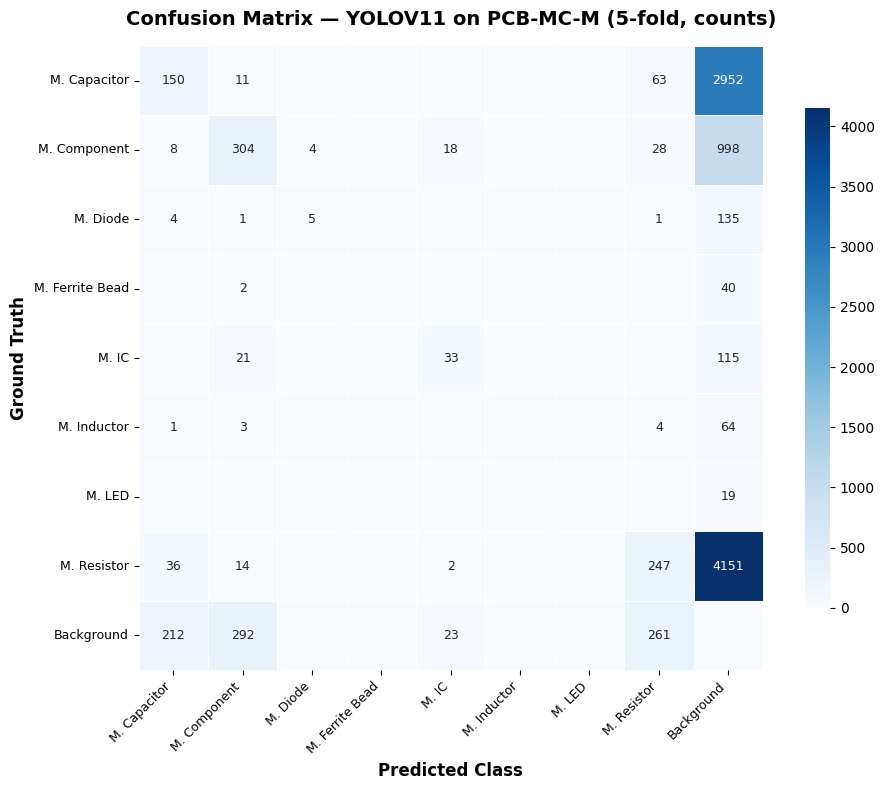

Saved: /content/drive/MyDrive/PCB_MC/figures/cm_yolov11_counts.png


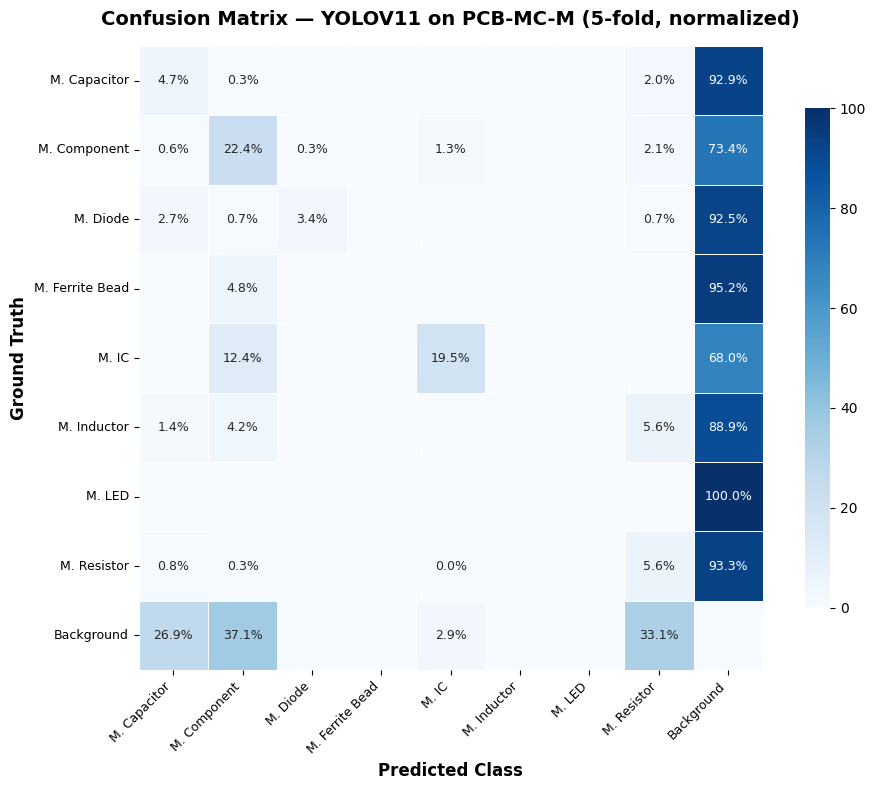

Saved: /content/drive/MyDrive/PCB_MC/figures/cm_yolov11_normalized.png


In [ ]:
# Labels for the matrix
# Shorten class names for readability
short_names = [c.replace('Missing ', 'M. ') for c in MISSING_CLASSES]
labels = short_names + ['Background']


def plot_confusion_matrix(cm, labels, title, save_path, normalize=False,
                          figsize=(10, 8), cmap='Blues', fontsize=9):
    """
    Plot a confusion matrix as a heatmap.

    Args:
        cm: confusion matrix (numpy array)
        labels: list of class labels
        title: plot title
        save_path: where to save the figure
        normalize: if True, normalize rows to percentages
        figsize: figure size
        cmap: colormap
        fontsize: font size for annotations
    """
    fig, ax = plt.subplots(figsize=figsize)

    if normalize:
        # Normalize each row (GT class) to sum to 100%
        row_sums = cm.sum(axis=1, keepdims=True).astype(float)
        row_sums[row_sums == 0] = 1  # avoid division by zero
        cm_plot = (cm.astype(float) / row_sums) * 100
        fmt = '.1f'
        annot_suffix = '%'
    else:
        cm_plot = cm.astype(float)
        fmt = '.0f'
        annot_suffix = ''

    # Create annotation labels
    annot = np.empty_like(cm_plot, dtype=object)
    for i in range(cm_plot.shape[0]):
        for j in range(cm_plot.shape[1]):
            val = cm_plot[i, j]
            if normalize:
                annot[i, j] = f'{val:.1f}%' if val > 0 else ''
            else:
                annot[i, j] = f'{int(val)}' if val > 0 else ''

    sns.heatmap(
        cm_plot,
        annot=annot,
        fmt='',
        cmap=cmap,
        xticklabels=labels,
        yticklabels=labels,
        square=True,
        linewidths=0.5,
        linecolor='white',
        cbar_kws={'shrink': 0.8},
        annot_kws={'size': fontsize},
        ax=ax,
    )

    ax.set_xlabel('Predicted Class', fontsize=12, fontweight='bold')
    ax.set_ylabel('Ground Truth', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)

    # Rotate tick labels
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')


# --- Plot 1: Absolute counts ---
plot_confusion_matrix(
    cm=cm_all,
    labels=labels,
    title=f'Confusion Matrix — {MODEL_NAME.upper()} on PCB-MC-M (5-fold, counts)',
    save_path=os.path.join(OUTPUT_DIR, f'cm_{MODEL_NAME}_counts.png'),
    normalize=False,
    cmap='Blues',
)

# --- Plot 2: Row-normalized (percentages) ---
plot_confusion_matrix(
    cm=cm_all,
    labels=labels,
    title=f'Confusion Matrix — {MODEL_NAME.upper()} on PCB-MC-M (5-fold, normalized)',
    save_path=os.path.join(OUTPUT_DIR, f'cm_{MODEL_NAME}_normalized.png'),
    normalize=True,
    cmap='Blues',
)

---
## [6] Per-Class Summary Statistics

Print recall, precision, and FNR per missing component class.

In [ ]:
print(f'Per-class statistics ({MODEL_NAME.upper()}, aggregated across 5 folds)')
print(f'{"":-<80}')
print(f'{"Class":<25} {"GT":>6} {"TP":>6} {"FP":>6} {"FN":>6} {"Prec":>8} {"Recall":>8} {"FNR":>8}')
print(f'{"":-<80}')

total_tp = 0
total_fp_all = 0
total_fn_all = 0

for i, cls_name in enumerate(MISSING_CLASSES):
    tp = cm_all[i, i]
    fn = cm_all[i, :].sum() - tp  # includes misclassifications + background
    fp = cm_all[:, i].sum() - tp  # other classes predicted as this class
    gt_total = cm_all[i, :].sum()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fnr = 1.0 - recall

    total_tp += tp
    total_fp_all += fp
    total_fn_all += fn

    print(f'{cls_name:<25} {gt_total:>6} {tp:>6} {fp:>6} {fn:>6} {precision:>8.3f} {recall:>8.3f} {fnr:>8.3f}')

print(f'{"":-<80}')
overall_prec = total_tp / (total_tp + total_fp_all) if (total_tp + total_fp_all) > 0 else 0.0
overall_rec = total_tp / (total_tp + total_fn_all) if (total_tp + total_fn_all) > 0 else 0.0
print(f'{"Overall":<25} {"":>6} {total_tp:>6} {total_fp_all:>6} {total_fn_all:>6} {overall_prec:>8.3f} {overall_rec:>8.3f} {1-overall_rec:>8.3f}')

Per-class statistics (YOLOV11, aggregated across 5 folds)
--------------------------------------------------------------------------------
Class                         GT     TP     FP     FN     Prec   Recall      FNR
--------------------------------------------------------------------------------
Missing Capacitor           3176    150    261   3026    0.365    0.047    0.953
Missing Component           1360    304    344   1056    0.469    0.224    0.776
Missing Diode                146      5      4    141    0.556    0.034    0.966
Missing Ferrite Bead          42      0      0     42    0.000    0.000    1.000
Missing IC                   169     33     43    136    0.434    0.195    0.805
Missing Inductor              72      0      0     72    0.000    0.000    1.000
Missing LED                   19      0      0     19    0.000    0.000    1.000
Missing Resistor            4450    247    357   4203    0.409    0.056    0.944
---------------------------------------------------

---
## [7] Generate Figure for the Paper

A cleaner version optimized for the EUVIP column width.
Uses only the 8 missing classes (no Background row/column)
to focus on inter-class confusion.

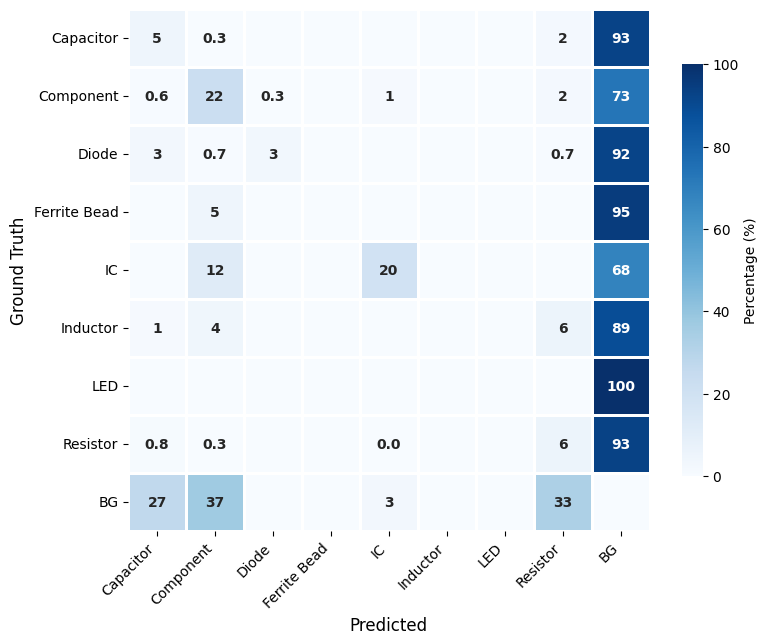

Saved: /content/drive/MyDrive/PCB_MC/figures/cm_yolov11_paper_with_bg.pdf


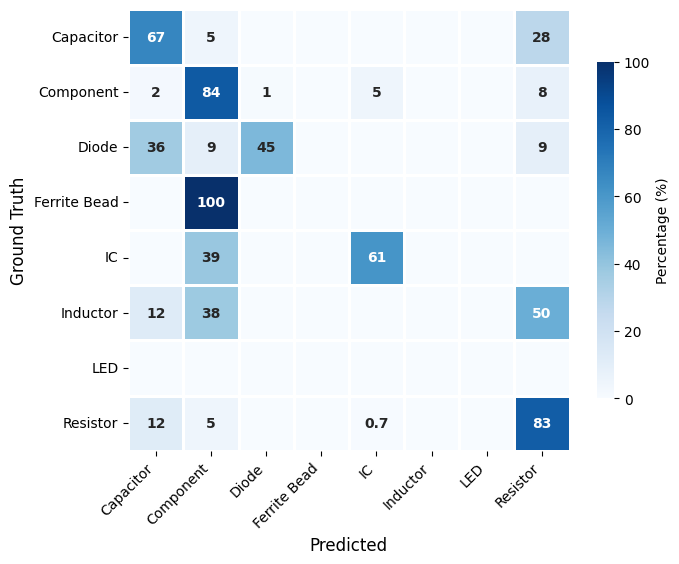

Saved: /content/drive/MyDrive/PCB_MC/figures/cm_yolov11_paper_no_bg.pdf


In [ ]:
def plot_paper_cm(cm_full, class_names, model_name, save_path,
                  include_background=True, figsize=(8, 7)):
    """
    Generate a publication-quality confusion matrix figure.
    """
    n = len(class_names)

    if include_background:
        cm = cm_full.copy()
        display_names = [c.replace('Missing ', '') for c in class_names] + ['BG']
    else:
        # Remove background row and column
        cm = cm_full[:n, :n].copy()
        display_names = [c.replace('Missing ', '') for c in class_names]

    # Row-normalize
    row_sums = cm.sum(axis=1, keepdims=True).astype(float)
    row_sums[row_sums == 0] = 1
    cm_norm = (cm / row_sums) * 100

    # Annotation
    annot = np.empty_like(cm_norm, dtype=object)
    for i in range(cm_norm.shape[0]):
        for j in range(cm_norm.shape[1]):
            val = cm_norm[i, j]
            if val >= 1:
                annot[i, j] = f'{val:.0f}'
            elif val > 0:
                annot[i, j] = f'{val:.1f}'
            else:
                annot[i, j] = ''

    fig, ax = plt.subplots(figsize=figsize)

    sns.heatmap(
        cm_norm,
        annot=annot,
        fmt='',
        cmap='Blues',
        xticklabels=display_names,
        yticklabels=display_names,
        square=True,
        linewidths=0.8,
        linecolor='white',
        vmin=0,
        vmax=100,
        cbar_kws={'shrink': 0.7, 'label': 'Percentage (%)'},
        annot_kws={'size': 10, 'fontweight': 'bold'},
        ax=ax,
    )

    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('Ground Truth', fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')


# Version WITH background (shows FN rate per class)
plot_paper_cm(
    cm_full=cm_all,
    class_names=MISSING_CLASSES,
    model_name=MODEL_NAME,
    save_path=os.path.join(OUTPUT_DIR, f'cm_{MODEL_NAME}_paper_with_bg.pdf'),
    include_background=True,
    figsize=(8, 7),
)

# Version WITHOUT background (focuses on inter-class confusion)
plot_paper_cm(
    cm_full=cm_all,
    class_names=MISSING_CLASSES,
    model_name=MODEL_NAME,
    save_path=os.path.join(OUTPUT_DIR, f'cm_{MODEL_NAME}_paper_no_bg.pdf'),
    include_background=False,
    figsize=(7, 6),
)

---
## [8] Run for Multiple Models (Optional)

If you want confusion matrices for all models, update the
checkpoint pattern and re-run cells [3]–[7] for each model.

Or use this loop to generate all at once.

In [ ]:
# ============================================================
# Uncomment to run for all models sequentially
# Update checkpoint patterns to match your file structure
# ============================================================

# MODELS = {
#     'yolov8': '/content/drive/MyDrive/PCB_MC/checkpoints/yolov8_fold_{}/best.pt',
#     'yolov11': '/content/drive/MyDrive/PCB_MC/checkpoints/yolov11_fold_{}/best.pt',
#     'yolo26': '/content/drive/MyDrive/PCB_MC/checkpoints/yolo26_fold_{}/best.pt',
#     'rtdetr': '/content/drive/MyDrive/PCB_MC/checkpoints/rtdetr_fold_{}/best.pt',
#     'dfine': '/content/drive/MyDrive/PCB_MC/checkpoints/dfine_fold_{}/best.pt',
# }
#
# all_cms = {}
# for model_name, ckpt_pattern in MODELS.items():
#     print(f'\n{"="*60}')
#     print(f'Processing {model_name}')
#     print(f'{"="*60}')
#
#     cm = np.zeros((num_classes + 1, num_classes + 1), dtype=int)
#     for fold in range(N_FOLDS):
#         ckpt = ckpt_pattern.format(fold)
#         if not os.path.exists(ckpt):
#             print(f'  Fold {fold}: checkpoint not found, skipping')
#             continue
#
#         model = YOLO(ckpt)
#         val_img_dir = os.path.join(
#             DATA_ROOT, SUBSET, 'kfold_data', f'fold_{fold}', 'valid', 'images'
#         )
#         results = model.predict(
#             source=val_img_dir, imgsz=IMG_SIZE, conf=CONF_THRESHOLD,
#             save_txt=True, save_conf=True,
#             project='/content/cm_preds', name=f'{model_name}_fold_{fold}',
#             exist_ok=True,
#         )
#         pred_dir = f'/content/cm_preds/{model_name}_fold_{fold}/labels'
#
#         # ... (same matching logic as cell [4])
#
#     all_cms[model_name] = cm
#     plot_paper_cm(
#         cm_full=cm, class_names=MISSING_CLASSES, model_name=model_name,
#         save_path=os.path.join(OUTPUT_DIR, f'cm_{model_name}_paper_with_bg.pdf'),
#     )

---
## Notes

**Interpreting the confusion matrix:**

- **Diagonal values** = correct detections (TP): the model found the right class at the right location
- **Off-diagonal values (within classes)** = misclassifications: the model found the location but assigned the wrong class
- **Background column** (last column) = false negatives: ground-truth boxes the model failed to detect
- **Background row** (last row) = false positives: predictions that do not match any ground-truth box

Given the high FNR (~0.87) observed in the detection experiments, expect the
Background column to dominate — most GT boxes are missed entirely.

**For the paper figure**, the version WITH background is more informative because
it shows how much of each class is missed (FN) vs. detected.